# 👾 PixelCNN using Tensorflow distributions

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions

In [5]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [6]:
# %load_ext autoreload
# %autoreload 2
import numpy as np

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import tensorflow_probability as tfp

# from notebooks.utils import display

In [18]:
import os
os.makedirs("./output", exist_ok=True)
os.makedirs("./logs", exist_ok=True)

## 0. Parameters <a name="parameters"></a>

In [8]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 10
BATCH_SIZE = 128

## 1. Prepare the data <a name="prepare"></a>

In [9]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
# Preprocess the data


def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs


input_data = preprocess(x_train)

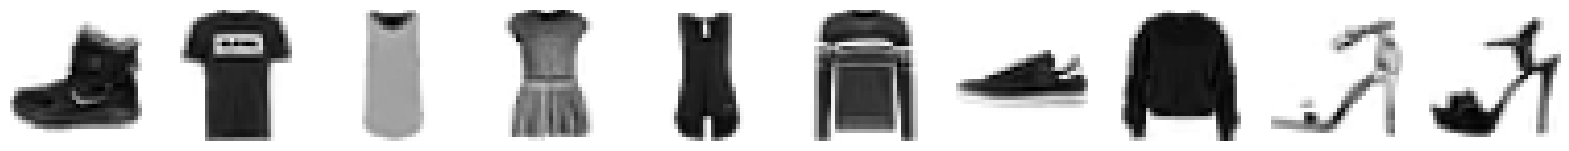

In [11]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [ ]:
# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,
    num_hierarchies=2,
    num_filters=32,
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Define the model input
# image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# # Define the log likelihood for the loss fn
# log_prob = dist.log_prob(image_input)

# Define the model input
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1), dtype=tf.float32)

# Wrap log_prob in a Keras layer
log_prob = layers.Lambda(lambda x: dist.log_prob(x))(image_input)

# Define the model
pixelcnn = models.Model(inputs=image_input, outputs=log_prob)
# there were issues with using the log_prob directly as a loss function, so added it as a loss function to the model via compile step
# pixelcnn.add_loss(-tf.reduce_mean(log_prob))

## 3. Train the PixelCNN <a name="train"></a>

In [15]:
# Compile and train the model
# pixelcnn.compile(
#     optimizer=optimizers.Adam(0.001),
# )

# 3. Define a custom loss function for .compile()
def negative_log_likelihood(y_true, y_pred):
    # y_pred is the log_prob output from the model
    # y_true is passed by Keras fit(), but we only minimize the negative log_prob
    return -tf.reduce_mean(y_pred)

# 4. Compile without add_loss
pixelcnn.compile(
    # optimizer='adam',
    optimizer=optimizers.Adam(0.001),
    loss=negative_log_likelihood
)

In [19]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    def on_epoch_end(self, epoch, logs=None):
        generated_images = self.generate()
        display(
            generated_images,
            n=self.num_img,
            save_to="./output/generated_img_%03d.png" % (epoch),
        )


img_generator_callback = ImageGenerator(num_img=2)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 4297.2849
Saved to ./output/generated_img_000.png


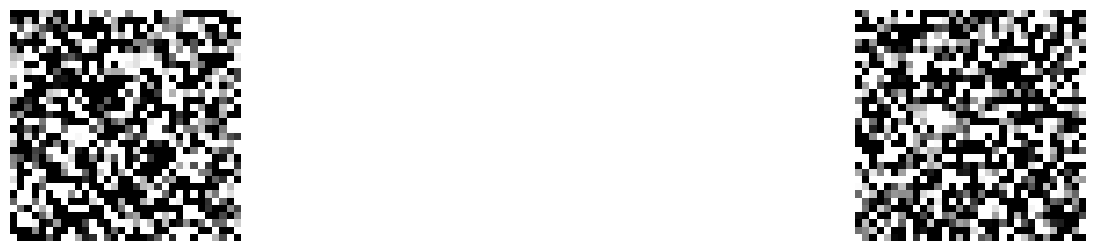

469/469 ━━━━━━━━━━━━━━━━━━━━ 120s 233ms/step - loss: 4296.3994
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4295.0941
Saved to ./output/generated_img_001.png


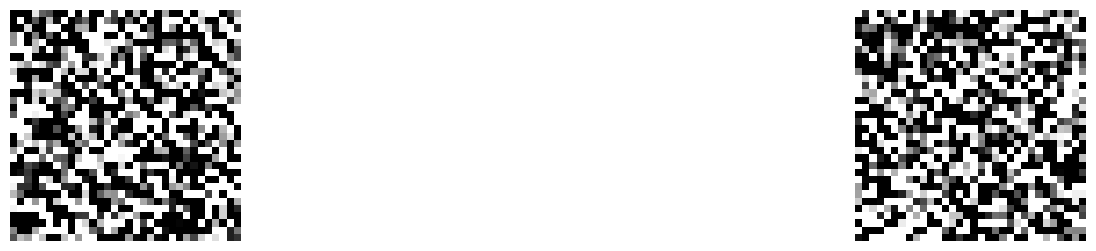

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 4296.3999
Epoch 3/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4293.4109
Saved to ./output/generated_img_002.png


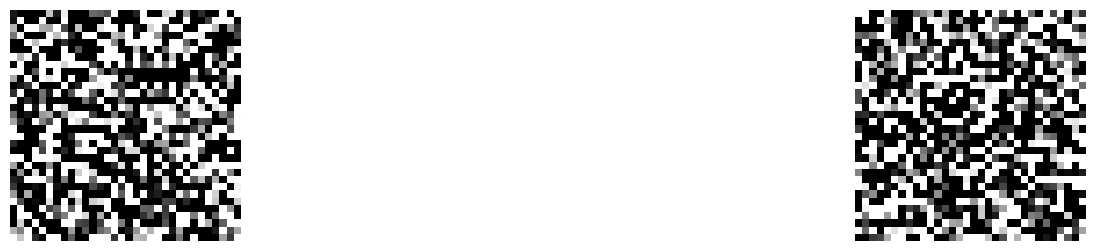

469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 4296.3984
Epoch 4/10
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4300.0070
Saved to ./output/generated_img_003.png


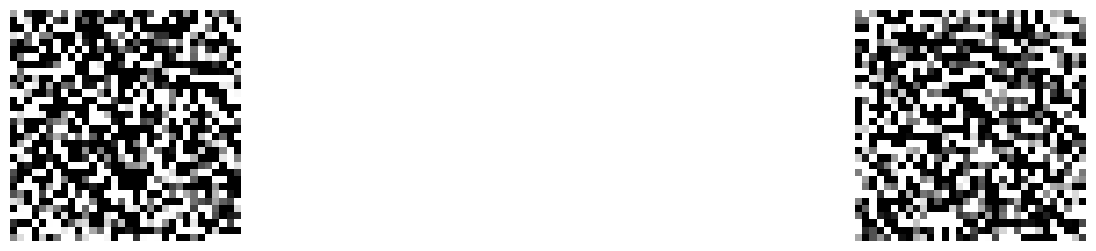

469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 213ms/step - loss: 4296.4004
Epoch 5/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4300.8180
Saved to ./output/generated_img_004.png


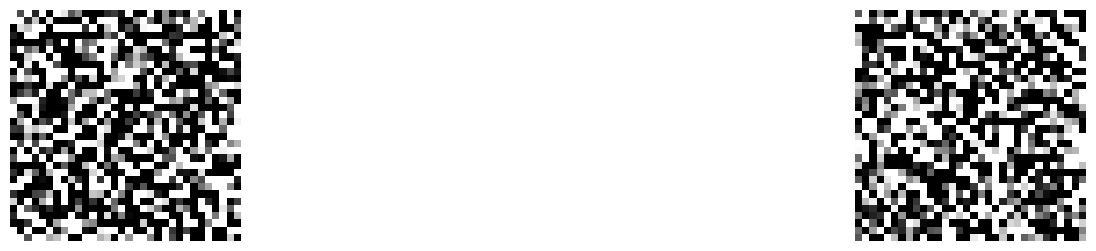

469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 4296.4004
Epoch 6/10
465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4295.3946
Saved to ./output/generated_img_005.png


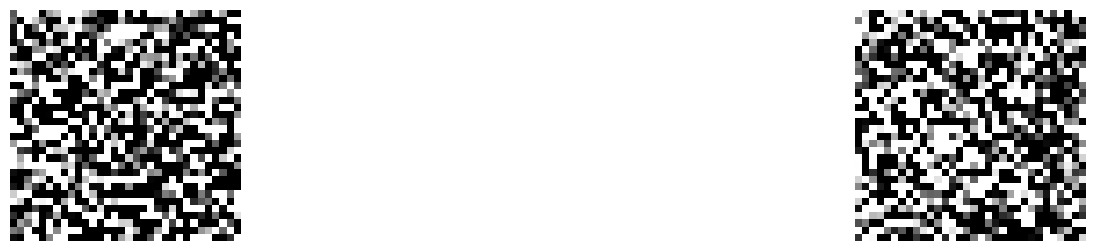

469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 4296.3994
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4296.6694
Saved to ./output/generated_img_006.png


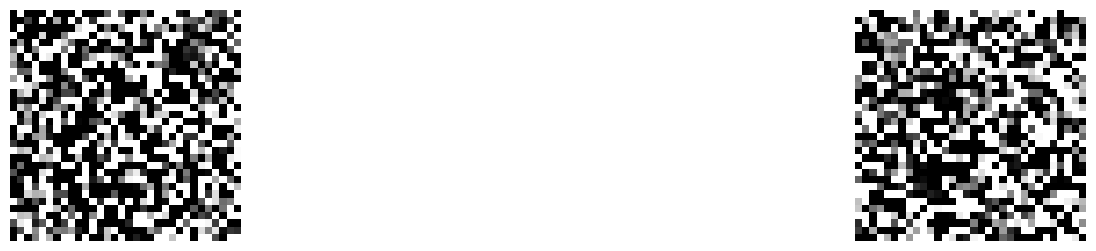

469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 210ms/step - loss: 4296.3994
Epoch 8/10
466/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4299.1888
Saved to ./output/generated_img_007.png


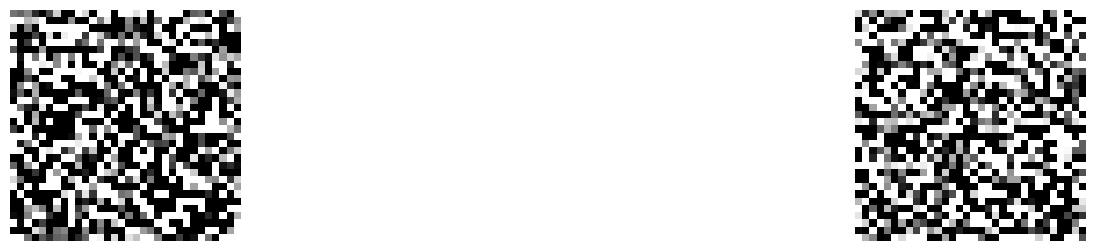

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 4296.3984
Epoch 9/10
467/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4299.3985
Saved to ./output/generated_img_008.png


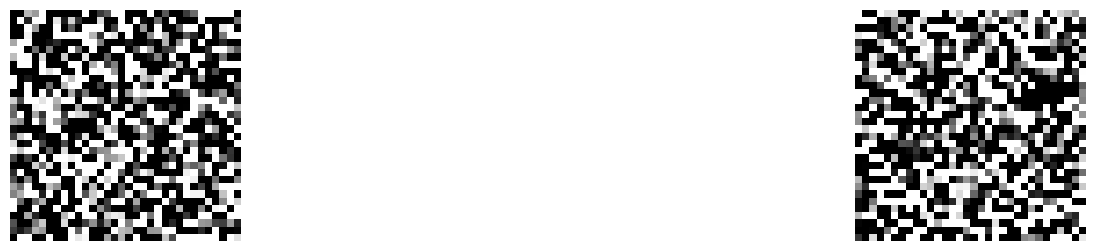

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4296.3999
Epoch 10/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4293.5091
Saved to ./output/generated_img_009.png


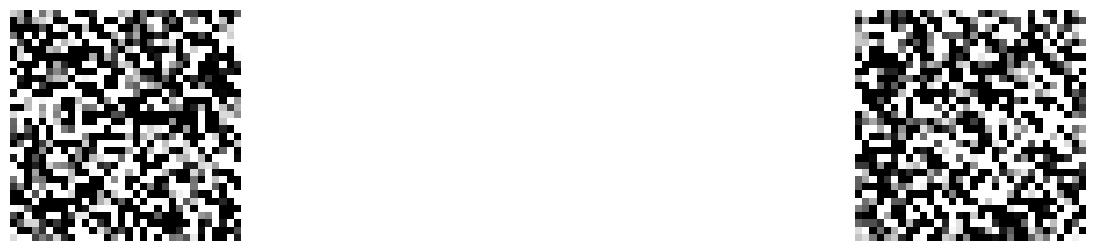

469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 210ms/step - loss: 4296.3999


In [21]:
# from Claude Haiky 4.5
# The issue is that fit() expects (X, y) pairs, but your model outputs log_prob which has incompatible shapes with the default target format. You need to provide dummy targets or use a custom training loop.
# The negative_log_likelihood loss function ignores y_true and only minimizes -tf.reduce_mean(y_pred), so the dummy targets are just placeholders for Keras' API.

# Create dummy targets (not actually used, loss only depends on y_pred)
dummy_targets = np.zeros(len(input_data))

pixelcnn.fit(
    input_data,
    dummy_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    verbose=True,
    callbacks=[tensorboard_callback, img_generator_callback],
)

## 4. Generate images <a name="generate"></a>

In [22]:
generated_images = img_generator_callback.generate()

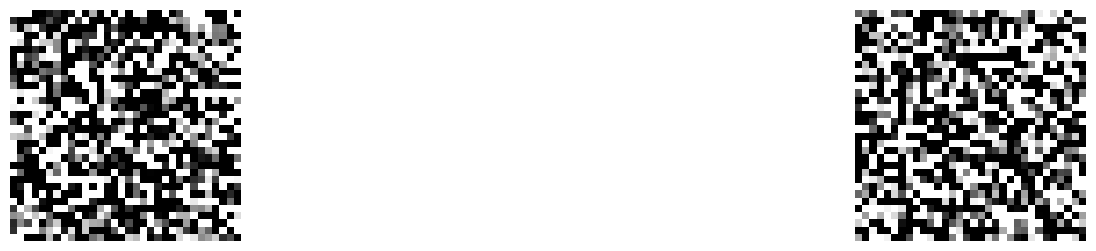

In [23]:
display(generated_images, n=img_generator_callback.num_img)